# 2 - Customer Churn Prediction - Classification

<img src='https://www.lytics.com/wp-content/uploads/2021/11/article-customerchurn1.jpg'>

Bu çalışmada e-ticaret müşteri verilerini kullanarak müşterinin sistemi bırakıp bırakmayacağını tahmin eden bir classification modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Train-test split
6. Classification modelleri kurma
7. En iyi modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen churn datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/E-commerce Customer Churn Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config',
 'ecommerce_customer_features.csv',
 'ecommerce_customer_targets.csv',
 'drive',
 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde özellik ve hedef dosyalarını okuyup birleştireceğim.

In [6]:
features_path = '/content/ecommerce_customer_features.csv'
targets_path = '/content/ecommerce_customer_targets.csv'

features_df = pd.read_csv(features_path)
targets_df = pd.read_csv(targets_path)

df = features_df.merge(targets_df, on='Customer_ID')
df.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


In [7]:
df.shape

(6000, 16)

In [8]:
df.columns.tolist()

['Customer_ID',
 'account_age_months',
 'avg_order_value',
 'total_orders',
 'days_since_last_purchase',
 'discount_usage_rate',
 'return_rate',
 'customer_support_tickets',
 'loyalty_member',
 'browsing_frequency_per_week',
 'cart_abandonment_rate',
 'product_review_score_avg',
 'engagement_score',
 'satisfaction_score',
 'price_sensitivity_index',
 'churned']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [10]:
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


## 3. Veri Temizleme

In [11]:
# Bu bölümde boş veri kontrolü yapacağım ve churn dağılımını inceleyeceğim.

In [12]:
df.isnull().sum()

,0
Customer_ID,0
account_age_months,0
avg_order_value,0
total_orders,0
days_since_last_purchase,0
discount_usage_rate,0
return_rate,0
customer_support_tickets,0
loyalty_member,0
browsing_frequency_per_week,0


In [13]:
df['churned'].value_counts()

,count
churned,
No,5071
Yes,929


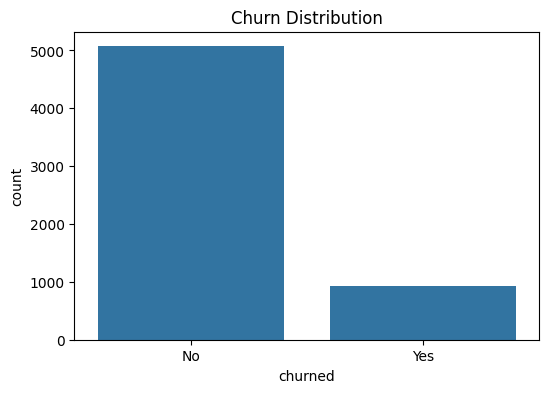

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='churned', data=df)
plt.title('Churn Distribution')
plt.show()

## 4. Feature Engineering

In [15]:
# Bu bölümde Customer_ID sütununu çıkarıp churn sütununu sayısal hale getireceğim.

In [16]:
df = df.drop('Customer_ID', axis=1)
df['churned'] = df['churned'].map({'No': 0, 'Yes': 1})

df = pd.get_dummies(df, drop_first=True)
df.head()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned,loyalty_member_Yes
0,46,164.96,12,17,0.243,0.1720,0,6.1,0.430,5.00,6.58,9.43,3.7,0,False
1,3,39.09,4,5,0.591,0.0808,1,4.1,0.183,4.44,6.25,8.50,6.9,0,False
2,29,37.42,8,47,0.212,0.1424,0,1.2,0.426,3.87,3.32,8.40,4.3,0,False
3,35,62.64,9,3,0.699,0.0128,0,3.8,0.730,4.75,6.42,9.71,7.5,0,False
4,39,113.03,1,7,0.382,0.0232,0,5.4,0.613,5.00,6.48,9.92,5.0,0,False


## 5. Train-Test Split

In [17]:
# Bu bölümde churn sütununu hedef değişken olarak ayırıp veriyi eğitim ve test olarak böleceğim.

In [18]:
x = df.drop('churned', axis=1)
y = df['churned']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train.shape, x_test.shape

((4800, 14), (1200, 14))

## 6. Classification Modelleri Kurma

In [19]:
# Bu bölümde birkaç farklı classification modeli kurup sonuçları karşılaştıracağım.

In [20]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, accuracy, f1])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1'])
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,F1
4,Extra Trees,0.972500,0.905983
0,Logistic Regression,0.965833,0.886427
2,Random Forest,0.965000,0.882022
3,Gradient Boosting,0.961667,0.874317
1,KNN,0.938333,0.771605


## 7. En İyi Modeli Değerlendirme

In [21]:
# Bu bölümde en başarılı modeli seçip detaylı sonuçlarını inceleyeceğim.

In [22]:
best_model_name = results_df.sort_values(by='F1', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(x_test)

print('Best Model:', best_model_name)
print('Accuracy:', accuracy_score(y_test, best_pred))
print('F1 Score:', f1_score(y_test, best_pred))
print(classification_report(y_test, best_pred))

Best Model: Extra Trees
Accuracy: 0.9725
F1 Score: 0.905982905982906
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1014
           1       0.96      0.85      0.91       186

    accuracy                           0.97      1200
   macro avg       0.97      0.92      0.94      1200
weighted avg       0.97      0.97      0.97      1200



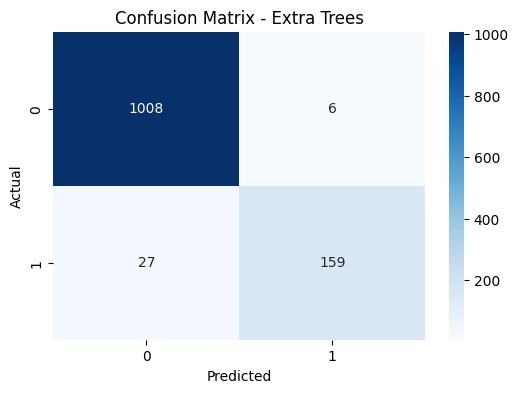

In [23]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [24]:
# Bu bölümde örnek bir müşteri verisi için churn tahmini yapacağım.

In [25]:
sample_customer = x_test.iloc[[0]]
sample_prediction = best_model.predict(sample_customer)[0]

print('Tahmin edilen churn durumu:', sample_prediction)
print('Gerçek değer:', y_test.iloc[0])

Tahmin edilen churn durumu: 1
Gerçek değer: 1


## 9. Sonuç

In [26]:
# Bu bölümde en iyi modeli yorumlayıp genel sonucu özetleyeceğim.

In [27]:
best_accuracy = results_df.sort_values(by='F1', ascending=False).iloc[0]['Accuracy']
best_f1 = results_df.sort_values(by='F1', ascending=False).iloc[0]['F1']

print(f"Bu projede en başarılı model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1 Score: {best_f1:.4f}")
print('Bu sonuca göre müşteri churn tahmininde en iyi performansı bu model verdi.')

Bu projede en başarılı model: Extra Trees
Accuracy: 0.9725
F1 Score: 0.9060
Bu sonuca göre müşteri churn tahmininde en iyi performansı bu model verdi.


Bu projede müşterinin churn edip etmeyeceğini tahmin etmek için farklı classification modelleri denendi. Elde edilen sonuçlara göre en başarılı model 0.9725 accuracy ve 0.9060 F1 score değeri ile Extra Trees oldu.